<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [4]:
import wget as wget

In [7]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [17]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv" 
df = pd.read_csv(url) 

**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [18]:
#!pip install pandas 
#!pip install matplotlib

#import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [19]:
# Read the CSV file
df = pd.read_csv(url)

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [22]:
import sqlite3

In [24]:
# Create a connection to the SQLite database
#conn = sqlite3.connect(url)

# Write the dataframe to the SQLite database
#df.to_sql('main', conn, if_exists='replace', index=False)

db_file = 'survey-data.sqlite'           # ← this is the local file name
conn = sqlite3.connect(db_file)          # ← creates the file if it doesn't exist

# Step 3: Write the DataFrame to the SQLite table
df.to_sql('main', conn, if_exists='replace', index=False)

# Step 4: Close connection (good practice)
conn.close()

print(f"Database successfully created: {db_file}")
print("Table 'main' contains all survey data.")
# Close the connection
conn.close()


Database successfully created: survey-data.sqlite
Table 'main' contains all survey data.


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [25]:
# Reconnect to the SQLite database
conn = sqlite3.connect(db_file)

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time       None  Apples   
4   Student, full-time       None  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                               None   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [26]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [27]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [28]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [29]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


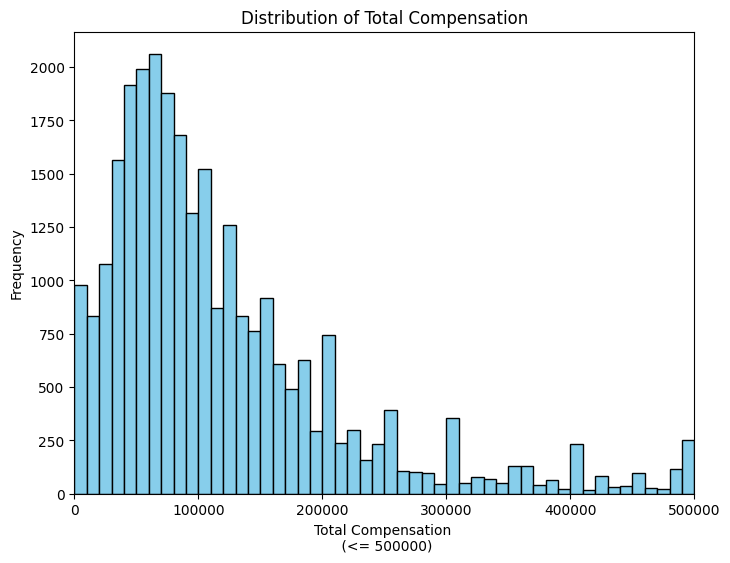

count     27766.000000
mean     115764.107289
std       97246.547185
min           0.000000
25%       50000.000000
50%       88000.000000
75%      150000.000000
max      500000.000000
Name: CompTotal, dtype: float64


In [31]:
query = """
SELECT CompTotal 
FROM main 
WHERE CompTotal IS NOT NULL
AND CompTotal <= '500000'
"""
comp_data = pd.read_sql_query(query, conn)
plt.figure(figsize=(8, 6))
plt.hist(comp_data['CompTotal'], bins=50, edgecolor='black', color='skyblue')
plt.title('Distribution of Total Compensation')
plt.xlabel('Total Compensation \n (<= 500000)')
plt.ylabel('Frequency')
plt.xlim(0, 500000)
plt.show()
print(comp_data['CompTotal'].describe())

**Box Plots**

Plot a box plot of Age.


In [32]:
import seaborn as sns

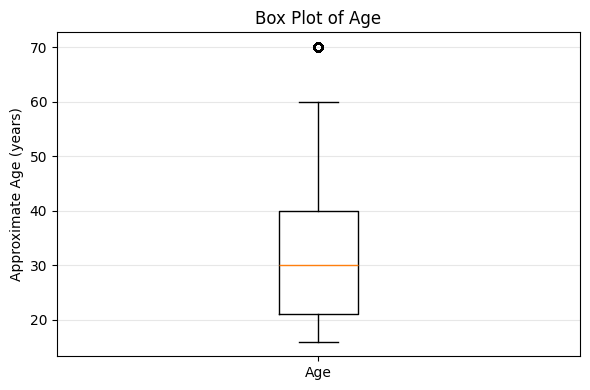

In [33]:
query = """
SELECT Age 
FROM main
WHERE Age IS NOT NULL
AND Age != 'Prefer not to say'
"""
age_data= pd.read_sql_query(query, conn)
age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

numeric_age = age_data['Age'].map(age_mapping).dropna()
plt.figure(figsize=(6, 4))
plt.boxplot(numeric_age, vert=True)
plt.title('Box Plot of Age')
plt.ylabel('Approximate Age (years)')
plt.xticks([1], ['Age'])
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


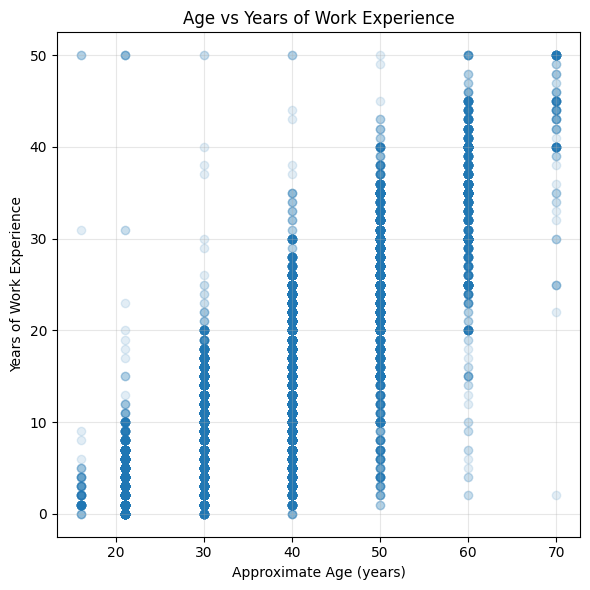

In [39]:
query = """
SELECT Age, WorkExp 
FROM main
WHERE Age IS NOT NULL 
AND WorkExp IS NOT NULL
AND Age != 'Prefer not to say'
"""
WorkExp_data = pd.read_sql_query(query, conn)

age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

WorkExp_data['Age_num'] = WorkExp_data['Age'].map(age_mapping)

# Drop rows with missing values
WorkExp_data = WorkExp_data.dropna(subset=['Age_num', 'WorkExp'])

plt.figure(figsize=(6, 6))
plt.scatter(WorkExp_data['Age_num'], WorkExp_data['WorkExp'], alpha=0.125)
plt.title('Age vs Years of Work Experience')
plt.xlabel('Approximate Age (years)')
plt.ylabel('Years of Work Experience')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


In [115]:
#conn = sqlite3.connect('survey-data.sqlite')
# Query distinct Frustration values (sorted for readability)
#query = """SELECT DISTINCT Frustration FROM main WHERE Frustration IS NOT NULL ORDER BY Frustration"""
#unique_frust = pd.read_sql_query(query, conn)['Frustration'].tolist()
#conn.close()
#print("All unique Frustration labels:")
#for label in unique_frust:
   #print("- " + label)

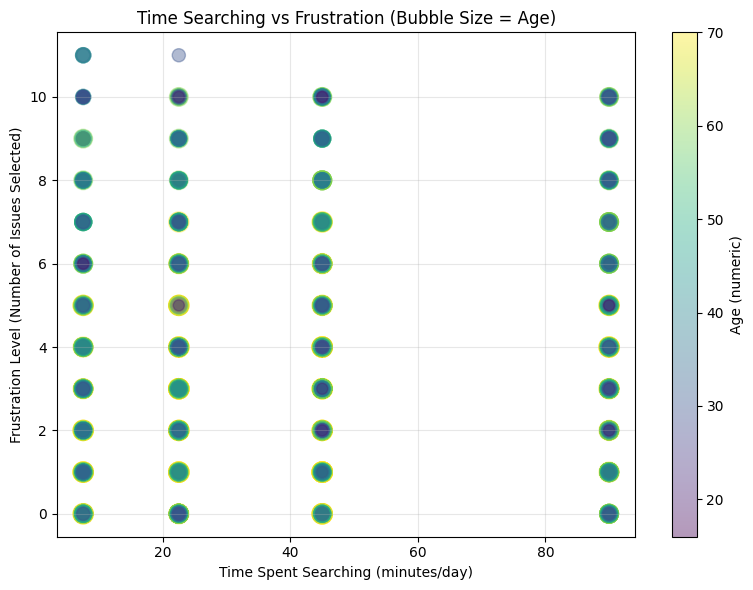

In [51]:
query = """
SELECT Age, TimeSearching, Frustration
FROM main
WHERE Age IS NOT NULL
AND TimeSearching IS NOT NULL
AND Frustration IS NOT NULL
AND Age != 'Prefer not to say'
"""
bubble_data = pd.read_sql_query(query, conn)

time_mapping = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    '2-4 hours a day': 180,
    '4-6 hours a day': 300,
    '6-8 hours a day': 420,
    'More than 8 hours a day': 500
}
bubble_data['Age_num'] = bubble_data['Age'].map(age_mapping)
bubble_data['TimeSearching_num'] = bubble_data['TimeSearching'].map(time_mapping)
bubble_data['FrustrationScore'] = bubble_data['Frustration'].apply(
    lambda x: 0 if x == 'None of these' else len(x.split(';'))
)
plt.figure(figsize=(8, 6))
plt.scatter(
    bubble_data['TimeSearching_num'],
    bubble_data['FrustrationScore'],
    s=bubble_data['Age_num'] * 3,
    alpha=0.4,
    c=bubble_data['Age_num'],  # color by age
    cmap='viridis'
)

plt.title('Time Searching vs Frustration (Bubble Size = Age)')
plt.xlabel('Time Spent Searching (minutes/day)')
plt.ylabel('Frustration Level (Number of Issues Selected)')
plt.colorbar(label='Age (numeric)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
print(bubble_data.shape)
print(bubble_data.head(15))

(28038, 4)
                Age               TimeSearching  \
0   35-44 years old         30-60 minutes a day   
1   35-44 years old         30-60 minutes a day   
2   45-54 years old        60-120 minutes a day   
3   25-34 years old         15-30 minutes a day   
4   25-34 years old  Less than 15 minutes a day   
5   45-54 years old        60-120 minutes a day   
6   35-44 years old         15-30 minutes a day   
7   35-44 years old         30-60 minutes a day   
8   25-34 years old        60-120 minutes a day   
9   35-44 years old        60-120 minutes a day   
10  25-34 years old         30-60 minutes a day   
11  25-34 years old         30-60 minutes a day   
12  35-44 years old        60-120 minutes a day   
13  35-44 years old        60-120 minutes a day   
14  25-34 years old         15-30 minutes a day   

                                          Frustration  Age_num  
0   Amount of technical debt;Number of software to...       40  
1   Amount of technical debt;Complexity of

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


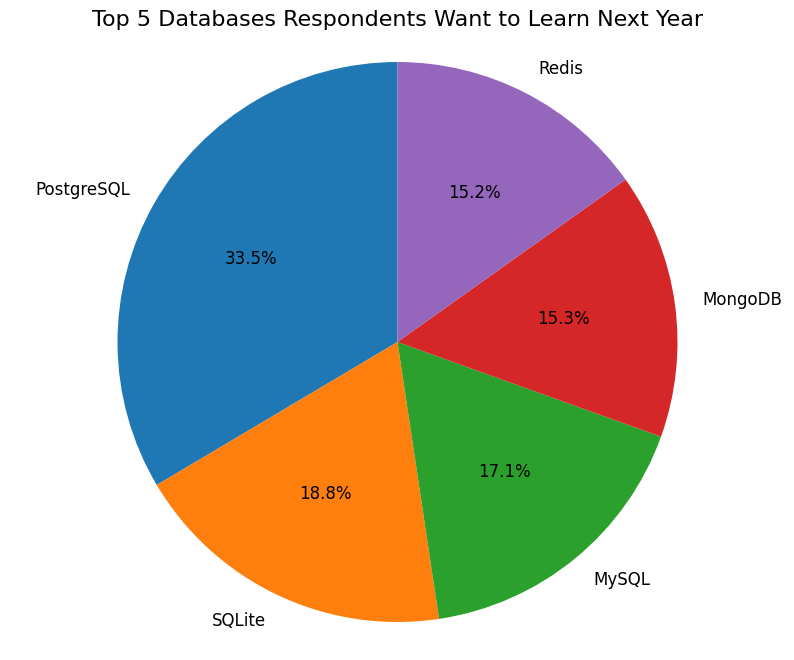

In [52]:
## Write your code here
query = "SELECT DatabaseWantToWorkWith FROM main"
df = pd.read_sql_query(query, conn)

# Drop missing values
df = df.dropna(subset=['DatabaseWantToWorkWith'])

# Split semicolon-separated values and count each database
databases = df['DatabaseWantToWorkWith'].str.split(';', expand=True).stack()

# Get the top 5 most wanted databases
top5 = databases.value_counts().head(5)

plt.figure(figsize=(10, 8))
plt.pie(top5, 
        labels=top5.index, 
        autopct='%1.1f%%',   # percentages
        startangle=90,
        textprops={'fontsize': 12})

plt.title('Top 5 Databases Respondents Want to Learn Next Year', fontsize=16)
plt.axis('equal')  # perfect circle
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


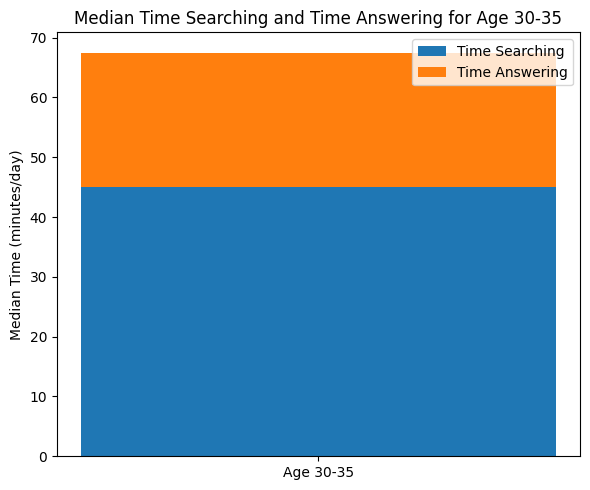

In [61]:
conn = sqlite3.connect('survey-data.sqlite')

query = """
SELECT Age, TimeSearching, TimeAnswering
FROM main
WHERE Age IS NOT NULL
AND TimeSearching IS NOT NULL
AND TimeAnswering IS NOT NULL
AND Age != 'Prefer not to say'
"""
df_times = pd.read_sql_query(query, conn)

# Map Age to numeric
age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df_times['Age_num'] = df_times['Age'].map(age_mapping)

# Filter for age 30-35
age_filtered = df_times[(df_times['Age_num'] >= 30) & (df_times['Age_num'] <= 35)].copy()

# Map TimeSearching and TimeAnswering to numeric
time_mapping = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    '2-4 hours a day': 180,
    '4-6 hours a day': 300,
    '6-8 hours a day': 420,
    'More than 8 hours a day': 500
}

# Use .loc to avoid SettingWithCopyWarning
age_filtered.loc[:, 'TimeSearching_num'] = age_filtered['TimeSearching'].map(time_mapping)
age_filtered.loc[:, 'TimeAnswering_num'] = age_filtered['TimeAnswering'].map(time_mapping)

# Compute medians
median_searching = age_filtered['TimeSearching_num'].median()
median_answering = age_filtered['TimeAnswering_num'].median()

plt.figure(figsize=(6,5))
plt.bar('Age 30-35', median_searching, label='Time Searching')
plt.bar('Age 30-35', median_answering, bottom=median_searching, label='Time Answering')
plt.ylabel('Median Time (minutes/day)')
plt.title('Median Time Searching and Time Answering for Age 30-35')
plt.legend()
plt.tight_layout()
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


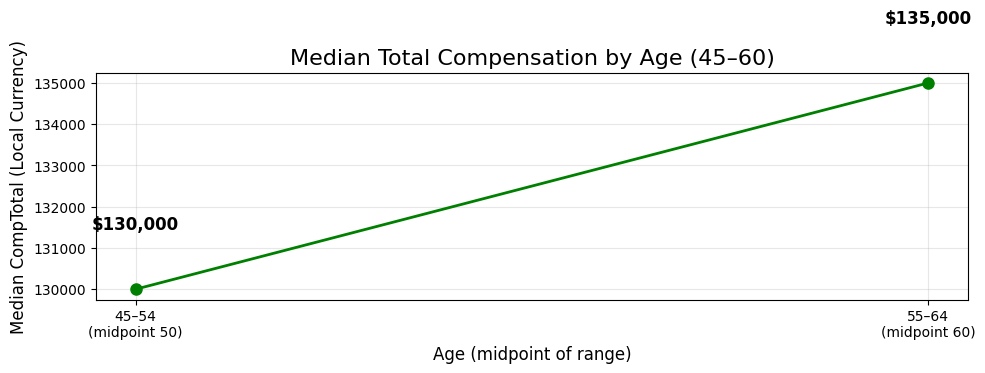

In [68]:
query = """
SELECT CompTotal, Age
FROM main
WHERE Age IN ('45-54 years old', '55-64 years old')
  AND CompTotal IS NOT NULL
"""
df = pd.read_sql_query(query, conn)

age_midpoint = {
    '45-54 years old': 50,
    '55-64 years old': 60
}
df['Age_mid'] = df['Age'].map(age_midpoint)

# Group by age midpoint and calculate median CompTotal
median_comp = df.groupby('Age_mid')['CompTotal'].median()

# data for line chart
ages = median_comp.index.tolist()        # [50, 60]
medians = median_comp.values.tolist()    # median values

plt.figure(figsize=(10, 4))
plt.plot(ages, medians, marker='o', linestyle='-', color='green', linewidth=2, markersize=8)

offset = max(medians) * 0.01  # 1% of max value 

for age, med in zip(ages, medians):
    plt.text(age, med + offset, f'${med:,.0f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Median Total Compensation by Age (45–60)', fontsize=16)
plt.xlabel('Age (midpoint of range)', fontsize=12)
plt.ylabel('Median CompTotal (Local Currency)', fontsize=12)
plt.grid(True, alpha=0.3)
#plt.ylim(0, max(medians) * 1.05)  # 5% padding above the max median
plt.xticks(ages, ['45–54\n(midpoint 50)', '55–64\n(midpoint 60)'])

plt.tight_layout()
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


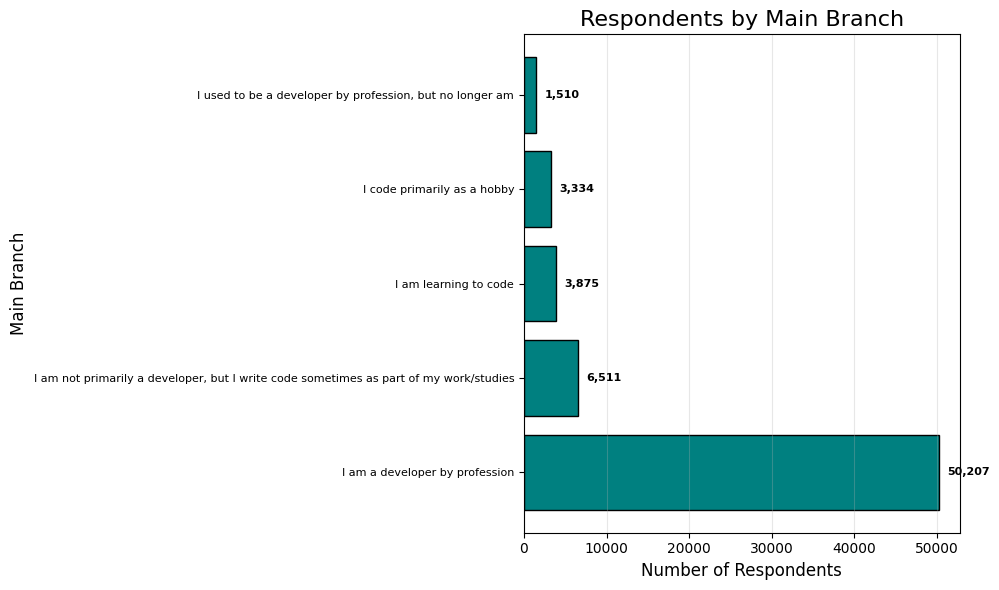

In [69]:
## Write your code here
conn = sqlite3.connect('survey-data.sqlite')

query = """
SELECT MainBranch
FROM main
WHERE MainBranch IS NOT NULL
  AND MainBranch != ''
"""
df = pd.read_sql_query(query, conn)

# Count the occurrences of each MainBranch category
mainbranch_counts = df['MainBranch'].value_counts()

plt.figure(figsize=(10, 6))

# horizontal bars
plt.barh(mainbranch_counts.index, mainbranch_counts.values, color='teal', edgecolor='black')

# value labels on the end of each bar
for i, (branch, count) in enumerate(mainbranch_counts.items()):
    plt.text(count + 1000, i, f'{count:,}', va='center', fontsize=8, fontweight='bold')

plt.title('Respondents by Main Branch', fontsize=16)
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Main Branch', fontsize=12)
plt.yticks(fontsize=8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [153]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
